# 과제: 100개의 임의 점 좌표에 대해 5-최근접 이웃 구하기 및 시각화

## 과제 설명
### 1. 목표: 100개의 임의의 2차원 좌표에 대해 각 점의 5-최근접 이웃을 찾아 시각화하는 프로그램을 작성.

### 2. 조건:
- 거리: 유클리드 거리 제곱을 사용하여 각 점 간의 거리를 계산.
- 출력: 각 점에 대해 가장 가까운 5개의 이웃 좌표를 출력.
- 시각화: 각 좌표와 해당 좌표에 가까운 5개의 이웃을 스캐터 플롯으로 시각화. (점마다 이웃 관계를 선으로 연결하여 표시)


### 3. 단계별 요구 사항
#### 3.1 난수 좌표 생성: 
- [0, 1) 범위에서 100개의 2차원 좌표를 생성.

#### 3.2 거리 행렬 계산: 
- 각 점 간의 유클리드 거리 제곱을 계산하여 100x100 크기의 거리 행렬을 생성.

#### 3.3 5-최근접 이웃 찾기: 
- 각 점에 대해 가장 가까운 5개의 점을 거리 순으로 정렬.
- 자기 자신을 제외하고 가장 가까운 5개의 이웃.

#### 3.4 결과 출력:
- 각 점에 대해 가장 가까운 5개의 이웃의 좌표와 거리 제곱을 출력.

#### 3.5 시각화:
- matplotlib를 사용하여 각 점과 해당 점의 5-최근접 이웃을 플롯.
- 각 점은 scatter로 표시하고, 가까운 이웃과 연결하는 선을 추가하여 관계를 시각적으로 표현.

[Point 00] coord=(0.3745, 0.9507)
  - NN#1: idx=69 | coord=(0.3636, 0.9718) | dist^2=0.000563
  - NN#2: idx=12 | coord=(0.4561, 0.7852) | dist^2=0.034050
  - NN#3: idx=53 | coord=(0.4104, 0.7556) | dist^2=0.039373
  - NN#4: idx=27 | coord=(0.5979, 0.9219) | dist^2=0.050721
  - NN#5: idx=79 | coord=(0.2376, 0.7282) | dist^2=0.068248

[Point 01] coord=(0.7320, 0.5987)
  - NN#1: idx=43 | coord=(0.7296, 0.6376) | dist^2=0.001519
  - NN#2: idx=46 | coord=(0.7608, 0.5613) | dist^2=0.002226
  - NN#3: idx=93 | coord=(0.8172, 0.5552) | dist^2=0.009152
  - NN#4: idx=47 | coord=(0.7710, 0.4938) | dist^2=0.012515
  - NN#5: idx=81 | coord=(0.6335, 0.5358) | dist^2=0.013650

[Point 02] coord=(0.1560, 0.1560)
  - NN#1: idx=07 | coord=(0.1818, 0.1834) | dist^2=0.001417
  - NN#2: idx=28 | coord=(0.0885, 0.1960) | dist^2=0.006159
  - NN#3: idx=54 | coord=(0.2288, 0.0770) | dist^2=0.011540
  - NN#4: idx=55 | coord=(0.2898, 0.1612) | dist^2=0.017912
  - NN#5: idx=49 | coord=(0.0254, 0.1079) | dist^2=0.019

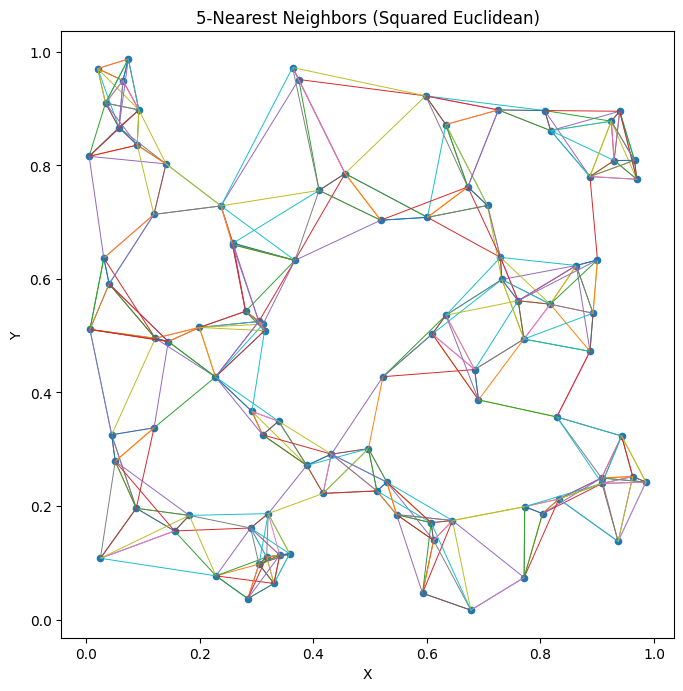

✅ 완료: neighbors_idx.shape = (100, 5) | D2 shape = (100, 100)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 3.1 난수 좌표 생성
np.random.seed(42)
N = 100
points = np.random.rand(N, 2)  # [0,1) 범위 2차원 좌표 (N,2)

# 3.2 거리 행렬 계산 (유클리드 거리 제곱)
# 거리 제곱: ||x - y||^2 = ||x||^2 + ||y||^2 - 2 x·y
sq_norms = np.sum(points**2, axis=1, keepdims=True)  # (N,1)
D2 = sq_norms + sq_norms.T - 2 * points @ points.T   # (N,N)
# 수치오차 보정(음수 매우 작은 값 → 0으로 클립)
D2 = np.clip(D2, 0.0, None)
# 자기 자신 제외
np.fill_diagonal(D2, np.inf)

# 3.3 5-최근접 이웃 찾기 (각 행별 최솟값 5개)
k = 5
# 우선 5개를 부분 정렬로 뽑고, 그 5개 안에서 정렬하여 최종 순서 보장
part = np.argpartition(D2, kth=k, axis=1)[:, :k]            # (N,k)
part_d2 = np.take_along_axis(D2, part, axis=1)              # (N,k)
order_in_part = np.argsort(part_d2, axis=1)                 # (N,k)
neighbors_idx = np.take_along_axis(part, order_in_part, axis=1)     # (N,k)
neighbors_d2  = np.take_along_axis(part_d2, order_in_part, axis=1)  # (N,k)

# 3.4 결과 출력 (각 점의 5-최근접 이웃: 인덱스, 좌표, 거리^2)
for i in range(N):
    print(f"[Point {i:02d}] coord=({points[i,0]:.4f}, {points[i,1]:.4f})")
    for r in range(k):
        j = neighbors_idx[i, r]
        d2 = neighbors_d2[i, r]
        print(f"  - NN#{r+1}: idx={j:02d} | coord=({points[j,0]:.4f}, {points[j,1]:.4f}) | dist^2={d2:.6f}")
    print()

# 3.5 시각화 (산점도 + 이웃 연결선)
plt.figure(figsize=(7, 7))
# 산점도
plt.scatter(points[:, 0], points[:, 1], s=20)
# 각 점에서 5개 이웃으로 선 연결
for i in range(N):
    xi, yi = points[i]
    for j in neighbors_idx[i]:
        xj, yj = points[j]
        plt.plot([xi, xj], [yi, yj], linewidth=0.7)

plt.title("5-Nearest Neighbors (Squared Euclidean)")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print("neighbors_idx.shape =", neighbors_idx.shape, "| D2 shape =", D2.shape)